### Estimating an AR Model
You will estimate the AR(1) parameter, 
, of one of the simulated series that you generated in the earlier exercise. Since the parameters are known for a simulated series, it is a good way to understand the estimation routines before applying it to real data.

For simulated_data_1 with a true 
 of 0.9, you will print out the estimate of 
. In addition, you will also print out the entire output that is produced when you fit a time series, so you can get an idea of what other tests and summary statistics are available in statsmodels.

- Import the class ARIMA in the module statsmodels.tsa.arima.model.
- Create an instance of the ARIMA class called mod using the simulated data simulated_data_1 and the order (p,d,q) of the model (in this case, for an AR(1)), is order=(1,0,0).
- Fit the model mod using the method .fit() and save it in a results object called res.
- Print out the entire summary of results using the .summary() method.
- Just print out an estimate of 
 using the .params[1] attribute (no parentheses).

In [ ]:
# Import the ARIMA module from statsmodels
from statsmodels.tsa.arima.model import ARIMA

# Fit an AR(1) model to the first simulated data
mod = ARIMA(simulated_data_1, order=(1,0,0))
res = mod.fit()

# Print out summary information on the fit
print(res.summary())

# Print out the estimate for phi
print("When the true phi=0.9, the estimate of phi is:")
print(res.params[1])

In [ ]:
                                   SARIMAX Results                                
    ==============================================================================
    Dep. Variable:                      y   No. Observations:                 1000
    Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1420.051
    Date:                Wed, 18 Sep 2024   AIC                           2846.103
    Time:                        20:42:47   BIC                           2860.826
    Sample:                             0   HQIC                          2851.699
                                   - 1000                                         
    Covariance Type:                  opg                                         
    ==============================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
    ------------------------------------------------------------------------------
    const         -0.3986      0.320     -1.247      0.212      -1.025       0.228
    ar.L1          0.9011      0.013     67.552      0.000       0.875       0.927
    sigma2         1.0005      0.045     22.239      0.000       0.912       1.089
    ===================================================================================
    Ljung-Box (L1) (Q):                   0.58   Jarque-Bera (JB):                 0.17
    Prob(Q):                              0.45   Prob(JB):                         0.92
    Heteroskedasticity (H):               1.00   Skew:                            -0.03
    Prob(H) (two-sided):                  0.99   Kurtosis:                         2.98
    ===================================================================================
    
    Warnings:
    [1] Covariance matrix calculated using the outer product of gradients (complex-step).
    When the true phi=0.9, the estimate of phi is:
   
0.9011059395968692

### Forecasting with an AR Model
In addition to estimating the parameters of a model that you did in the last exercise, you can also do forecasting, both in-sample and out-of-sample using statsmodels. The in-sample is a forecast of the next data point using the data up to that point, and the out-of-sample forecasts any number of data points in the future. You can plot the forecasted data using the function plot_predict(). You supply the starting point for forecasting and the ending point, which can be any number of data points after the data set ends.

For the simulated data in DataFrame simulated_data_1, with phi = 0.9
, you will plot out-of-sample forecasts and confidence intervals around those forecasts.

- Import the class ARIMA and also import the function plot_predict
- Create an instance of the ARIMA class called mod using the simulated data in DataFrame simulated_data_1 and the order (p,d,q) of the model (in this case, for an AR(1)), order=(1,0,0)
- Fit the model mod using the method .fit() and save it in a results object called res
- Plot the in-sample data starting with data point 950
- Plot out-of-sample forecasts of the data and confidence intervals using the plot_predict() function, starting where the data ends at the 1000th point, and ending the forecast at point 1010

In [ ]:
# Import the ARIMA and plot_predict from statsmodels
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_predict

# Forecast the first AR(1) model
mod = ARIMA(simulated_data_1, order=(1,0,0))
res = mod.fit()

# Plot the data and the forecast
fig, ax = plt.subplots()
simulated_data_1.loc[950:].plot(ax=ax)
plot_predict(res, start=1000, end=1010, ax=ax)
plt.show()

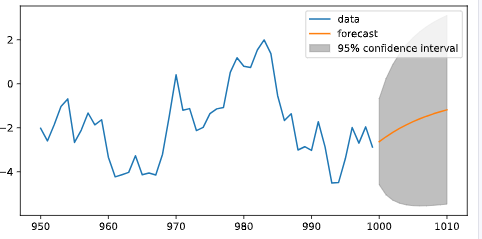

### Let's Forecast Interest Rates
You will now use the forecasting techniques you learned in the last exercise and apply it to real data rather than simulated data. You will revisit a dataset from the first chapter: the annual data of 10-year interest rates going back 56 years, which is in a Series called interest_rate_data. Being able to forecast interest rates is of enormous importance, not only for bond investors but also for individuals like new homeowners who must decide between fixed and floating rate mortgages.

You saw in the first chapter that there is some mean reversion in interest rates over long horizons. In other words, when interest rates are high, they tend to drop and when they are low, they tend to rise over time. Currently they are below long-term rates, so they are expected to rise, but an AR model attempts to quantify how much they are expected to rise.

The class ARIMA and the function plot_predict have already been imported.

- Create an instance of the ARIMA class called mod using the annual interest rate data and choosing the order for an AR(1) model.
- Fit the model mod using the method .fit() and save it in a results object called res.
- Plot the data and the in-sample and out-of-sample forecasts of the data using the .plot_predict() function.
    - The first argument of plot_predict() should be the fitted model.
    - Pass the arguments start=0 to start the in-sample forecast from the beginning, and choose end to be '2027' to forecast several years in the future.
    - Note that the end argument 2027 must be in quotes here since it represents a date and not an integer position.

# Forecast interst rates using an AR(1) model
mod = ARIMA(interest_rate_data, order=(1,0,0))
res = mod.fit()

# Plot the data and the forecast
fig, ax = plt.subplots()
interest_rate_data.plot(ax=ax)
plot_predict(res, start=0, end='2027', alpha=None, ax=ax)
plt.show()

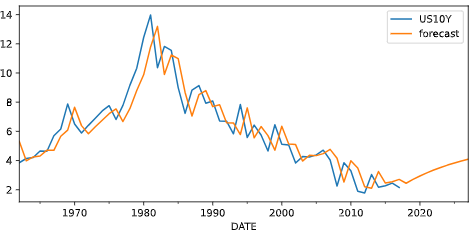

### Compare AR Model with Random Walk
Sometimes it is difficult to distinguish between a time series that is slightly mean reverting and a time series that does not mean revert at all, like a random walk. You will compare the ACF for the slightly mean-reverting interest rate series of the last exercise with a simulated random walk with the same number of observations.

You should notice when plotting the autocorrelation of these two series side-by-side that they look very similar.

- Import plot_acf function from the statsmodels module
- Create two axes for the two subplots
- Plot the autocorrelation function for 12 lags of the interest rate series interest_rate_data in the top plot
- Plot the autocorrelation function for 12 lags of the interest rate series simulated_data in the bottom plot

In [ ]:
# Import the plot_acf module from statsmodels
from statsmodels.graphics.tsaplots import plot_acf

# Plot the interest rate series and the simulated random walk series side-by-side
fig, axes = plt.subplots(2,1)

# Plot the autocorrelation of the interest rate series in the top plot
fig = plot_acf(interest_rate_data, alpha=1, lags=12, ax=axes[0])

# Plot the autocorrelation of the simulated random walk series in the bottom plot
fig = plot_acf(simulated_data, alpha=1, lags=12, ax=axes[1])

# Label axes
axes[0].set_title("Interest Rate Data")
axes[1].set_title("Simulated Random Walk Data")
plt.show()

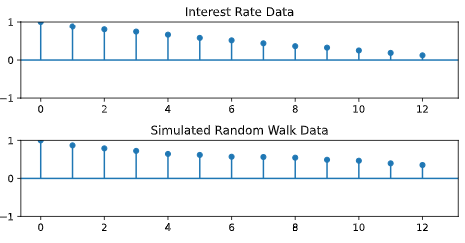

### Estimate Order of Model: PACF
One useful tool to identify the order of an AR model is to look at the Partial Autocorrelation Function (PACF). In this exercise, you will simulate two time series, an AR(1) and an AR(2), and calculate the sample PACF for each. You will notice that for an AR(1), the PACF should have a significant lag-1 value, and roughly zeros after that. And for an AR(2), the sample PACF should have significant lag-1 and lag-2 values, and zeros after that.

Just like you used the plot_acf function in earlier exercises, here you will use a function called plot_pacf in the statsmodels module.

- Import the modules for simulating data and for plotting the PACF
- Simulate an AR(1) with 
 (remember that the sign for the AR parameter is reversed)
- Plot the PACF for simulated_data_1 using the plot_pacf function
- Simulate an AR(2) with 
 (again, reverse the signs)
- Plot the PACF for simulated_data_2 using the plot_pacf function

In [ ]:
# Import the modules for simulating data and for plotting the PACF
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_pacf

# Simulate AR(1) with phi=+0.6
ma = np.array([1])
ar = np.array([1, -0.6])
AR_object = ArmaProcess(ar, ma)
simulated_data_1 = AR_object.generate_sample(nsample=5000)

# Plot PACF for AR(1)
plot_pacf(simulated_data_1, lags=20)
plt.show()

# Simulate AR(2) with phi1=+0.6, phi2=+0.3
ma = np.array([1])
ar = np.array([1, -0.6, -0.3])
AR_object = ArmaProcess(ar, ma)
simulated_data_2 = AR_object.generate_sample(nsample=5000)

# Plot PACF for AR(2)
plot_pacf(simulated_data_2, lags=20)
plt.show()

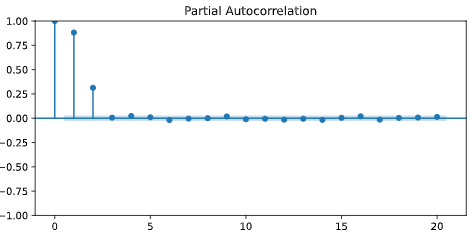

### Estimate Order of Model: Information Criteria
Another tool to identify the order of a model is to look at the Akaike Information Criterion (AIC) and the Bayesian Information Criterion (BIC). These measures compute the goodness of fit with the estimated parameters, but apply a penalty function on the number of parameters in the model. You will take the AR(2) simulated data from the last exercise, saved as simulated_data_2, and compute the BIC as you vary the order, p, in an AR(p) from 0 to 6.

- Import the ARIMA module for estimating the parameters and computing BIC.
- Initialize a numpy array BIC, which we will use to store the BIC for each AR(p) model.
- Loop through order p for p = 0,…,6.
- For each p, fit the data to an AR model of order p.
- For each p, save the value of BIC using the .bic attribute (no parentheses) of res.
- Plot BIC as a function of p (for the plot, skip p=0 and plot for p=1,…6).

In [ ]:
# Import the module for estimating an ARIMA model
from statsmodels.tsa.arima.model import ARIMA

# Fit the data to an AR(p) for p = 0,...,6 , and save the BIC
BIC = np.zeros(7)
for p in range(7):
    mod = ARIMA(simulated_data_2, order=(p,0,0))
    res = mod.fit()
# Save BIC for AR(p)    
    BIC[p] = res.bic
    
# Plot the BIC as a function of p
plt.plot(range(1,7), BIC[1:7], marker='o')
plt.xlabel('Order of AR Model')
plt.ylabel('Bayesian Information Criterion')
plt.show()

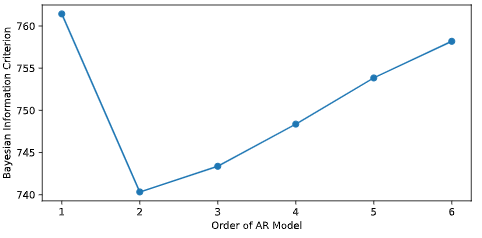